In [1]:
from pathlib import Path

import hdbscan
import numpy as np
import pandas as pd
import umap
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from visualization.plot import plot_clustering_on_umap
from visualization.samples_plot import show_clustering_samples

PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

2026-07-06 11:10:38.501470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


1664


In [2]:
X_reduced_variance = VarianceThreshold(threshold=1e-8).fit_transform(embedding)

embedding_scaled = StandardScaler().fit_transform(X_reduced_variance)

pca_95 = PCA(n_components=0.95, svd_solver="full")
pca_95_embedding = pca_95.fit_transform(embedding_scaled)

print("Shape dopo PCA:", pca_95_embedding.shape)

pca_95_embedding_l2 = normalize(pca_95_embedding, norm="l2")

Shape dopo PCA: (677, 315)


In [6]:
labels_for_consensus = []
umap_embeddings_for_consensus = []

for run in range(1, 31):
    umap_embedding = umap.UMAP(
        n_neighbors=int(0.075 * n_samples),        #umap_params["n_neighbors"],
        min_dist=0.05,               #umap_params["min_dist"],
        n_components=20,       #umap_params["n_components"],
        metric="euclidean"         #umap_params["metric"],
    ).fit_transform(pca_95_embedding_l2)

    CLUSTER_SELECTION_METHOD = "eom"

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=round(0.03 * n_samples),               #hdbscan_params["min_cluster_size"],
        min_samples=5,            #round(0.01 * n_samples),  #          hdbscan_params["min_samples"],
        metric="euclidean",         #hdbscan_params["metric"],
        cluster_selection_method=CLUSTER_SELECTION_METHOD       #hdbscan_params["cluster_selection_method"]
    )

    labels = clusterer.fit_predict(umap_embedding)

    labels_for_consensus.append(labels)
    umap_embeddings_for_consensus.append(umap_embedding)


In [7]:
from clustering.consensus import consensus_clustering_from_labels

consensus_labels, probabilities = consensus_clustering_from_labels(
    labels_for_consensus,
    max_noise_frequency=0.33,
    min_consensus_strength=0.70
)

In [8]:
from clustering.consensus_dbcv import dbcv_per_cluster_consensus

dbcv_consensus = dbcv_per_cluster_consensus(
    consensus_labels,
    umap_embeddings_for_consensus
)

dbcv_consensus

,cluster,cluster_relabelled,size,is_noise,dbcv_mean,dbcv_std,dbcv_min,dbcv_max,dbcv_median,n_runs_valid,global_dbcv_mean,global_dbcv_std
0,-1,-1,97,True,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,0,0,136,NaN,0.379391,0.079032,0.208279,0.494131,0.384827,30,0.468818,0.039889
2,1,1,46,NaN,0.542129,0.106221,0.352380,0.703838,0.558633,30,0.468818,0.039889
3,2,2,333,NaN,0.487650,0.058896,0.351018,0.591072,0.490543,30,0.468818,0.039889
4,3,3,37,NaN,0.432507,0.121659,0.063007,0.663078,0.431301,30,0.468818,0.039889
5,4,4,28,NaN,0.606747,0.068306,0.458034,0.729291,0.612413,30,0.468818,0.039889


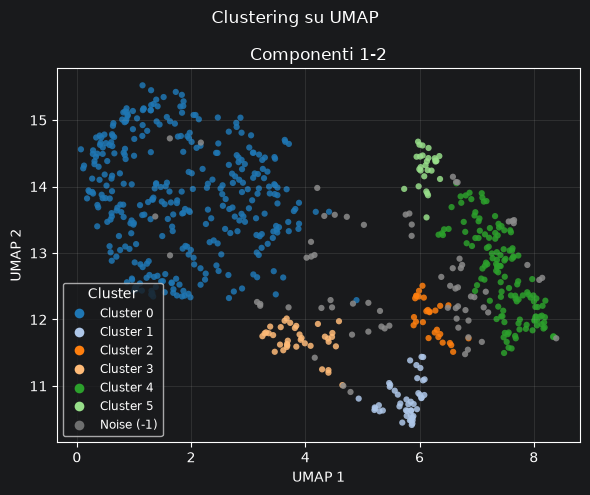

(<Figure size 600x500 with 1 Axes>,
 (<Axes: title={'center': 'Componenti 1-2'}, xlabel='UMAP 1', ylabel='UMAP 2'>,))

In [14]:
plot_clustering_on_umap(
    pca_95_embedding_l2,
    consensus_labels,
    metric="euclidean",
    min_dist=0.05,
    n_neighbors=int(0.075 * n_samples)        #umap_params["n_neighbors"],
)

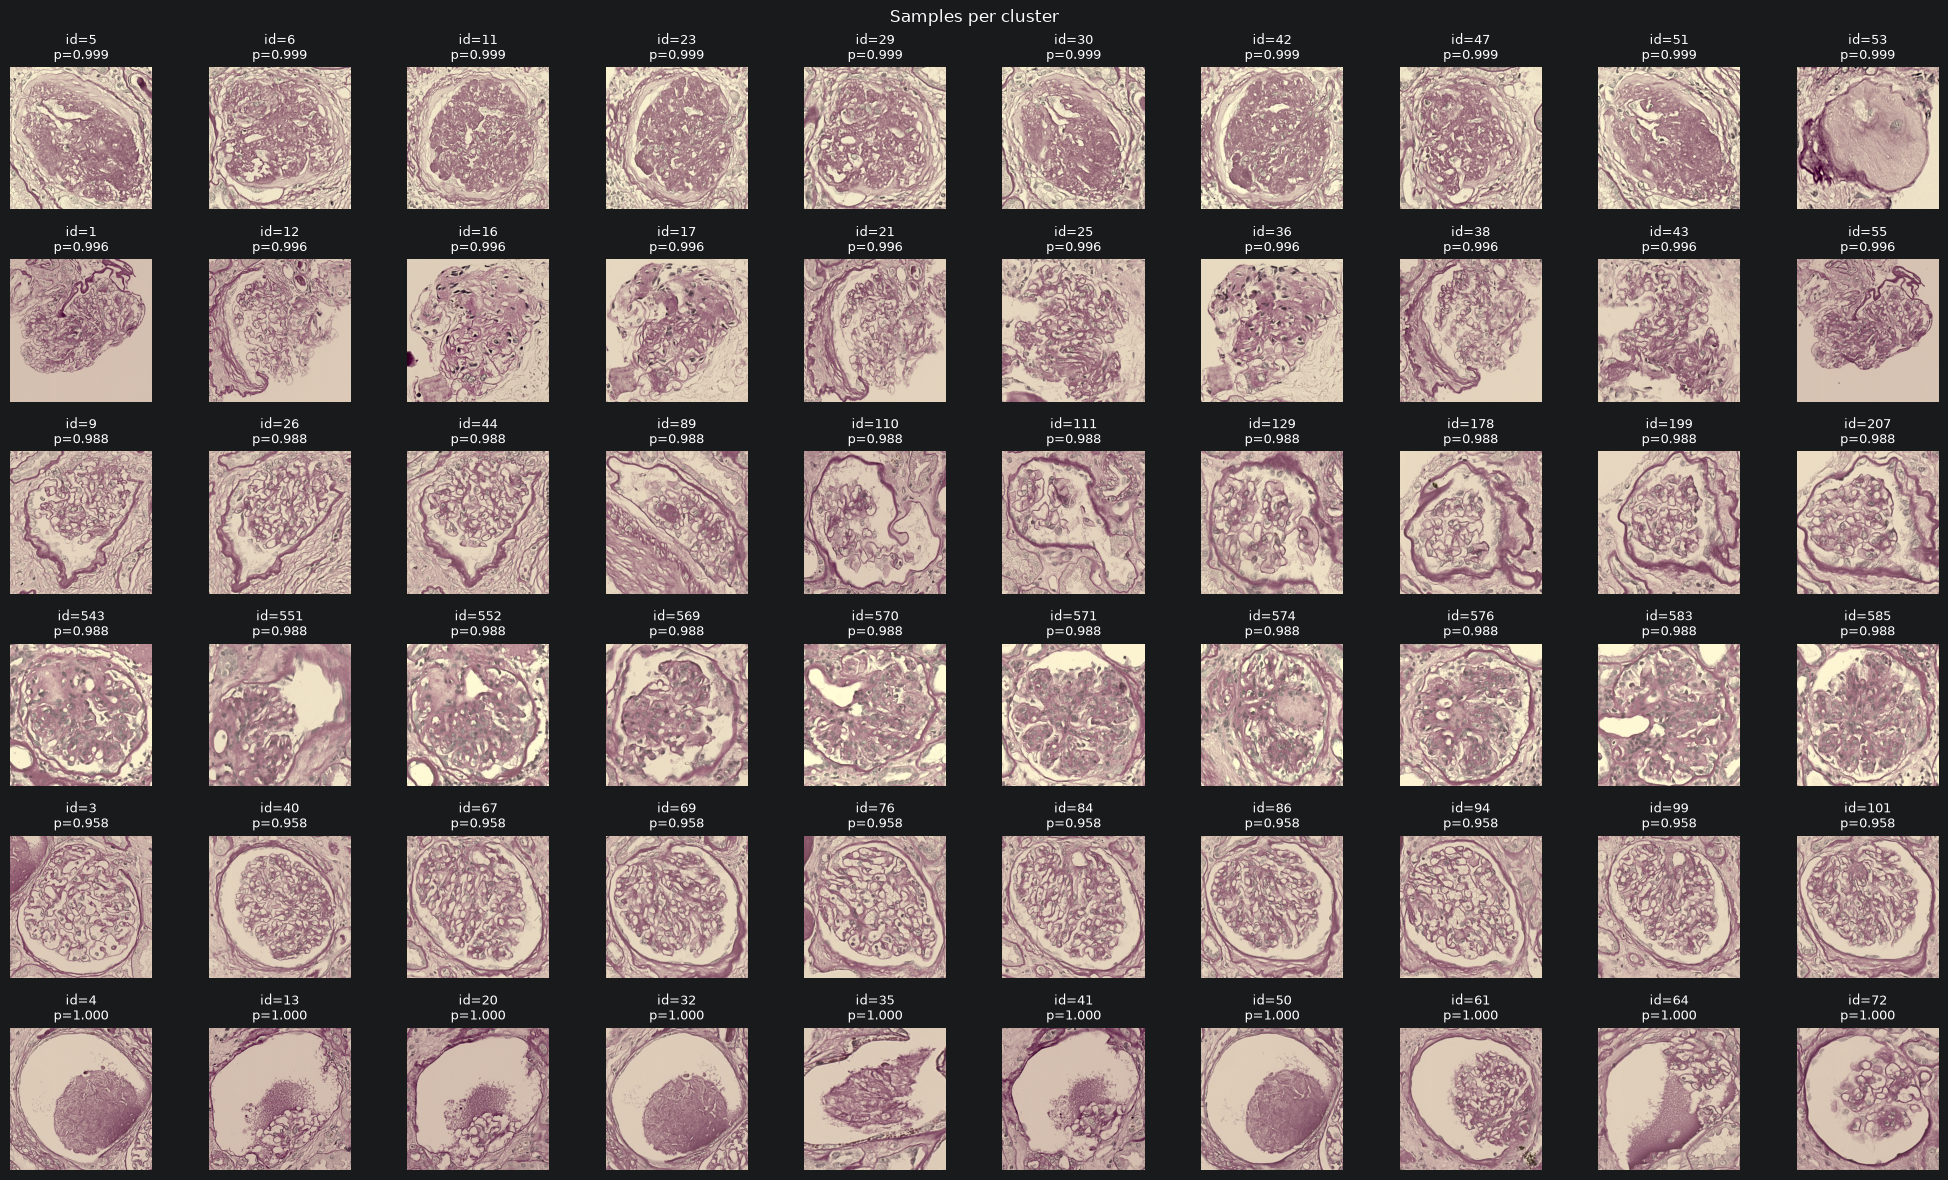

In [15]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=consensus_labels,
    probabilities=probabilities,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [8]:
from sklearn.metrics import pairwise_distances


def pair_rank_report(X, idx_a, idx_b, metric="cosine", name="space"):
    """
    Dice quanto idx_b ﷿﷿﷿﷿﷿﷿ vicino a idx_a nello spazio X.
    rank = 1 significa vicino pi﷿﷿﷿﷿﷿﷿ vicino.
    rank alto significa lontano.
    """
    D = pairwise_distances(X, X[[idx_a]], metric=metric).ravel()

    order = np.argsort(D)
    order = order[order != idx_a]  # rimuove s﷿﷿﷿﷿﷿﷿ stesso

    rank_b = np.where(order == idx_b)[0][0] + 1
    dist_ab = D[idx_b]

    percent_rank = rank_b / (len(X) - 1) * 100

    print(f"\n{name}")
    print(f"metric: {metric}")
    print(f"distanza {idx_a} -> {idx_b}: {dist_ab:.4f}")
    print(f"rank del secondo rispetto al primo: {rank_b}/{len(X)-1}")
    print(f"percentile rank: {percent_rank:.2f}%")

    return {
        "space": name,
        "distance": dist_ab,
        "rank": rank_b,
        "percent_rank": percent_rank,
    }

In [9]:
ID_SCLEROTIC = 4
ID_OPEN = 3

In [10]:
# Distanza originale tra due punti nello spazio embedding
report_pre = pair_rank_report(
    embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="PRE-UMAP"
)

post_variance_threshold = pair_rank_report(
    X_reduced_variance,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-VarianceThreshold"
)

post_pca = pair_rank_report(
    pca_95_embedding_l2,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-PCA"
)

post_umap = pair_rank_report(
    umap_embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="euclidean",
    name="POST-UMAP"
)


PRE-UMAP
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-VarianceThreshold
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-PCA
metric: cosine
distanza 4 -> 3: 0.8990
rank del secondo rispetto al primo: 117/676
percentile rank: 17.31%

POST-UMAP
metric: euclidean
distanza 4 -> 3: 2.2284
rank del secondo rispetto al primo: 157/676
percentile rank: 23.22%
